# **Intership Task 2**

# Exploring the famous Titanic Dataset




In [ ]:
#Reading the csv file

#Importing python libraries

#Displaying the dataset

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("/Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# **Exploratory Data Analysis**

# Data Cleaning




In [ ]:
 #Finding the missing values on the dataset

 #Handle the missing values

 #Using the fillna command

 #Displaying the missing values in tabular form

In [ ]:
df['Age'] = df['Age'].fillna(df["Age"].median())
display(df.Age)

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode([0]))
display(df.Embarked)

df.isnull().sum().to_frame(name="Missing Values")


,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,28.0
889,26.0


,Embarked
0,S
1,C
2,S
3,S
4,S
...,...
886,S
887,S
888,S
889,C


,Missing Values
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


# Analysing the Data

In [ ]:
survival_by_sex = df.groupby("Sex")["Survived"].sum().to_frame("Count")
display(survival_by_sex)

survival_by_class = df.groupby('Pclass')['Survived'].sum().to_frame("Value")
display(survival_by_class)

bins = [0, 10, 20, 30, 40, 50, 60, 70, 80]
labels = ["0-10", "11-20", "21-30", "31-40", "41-50", "51-60", "61-70", "71-80"]

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

survival_by_age = (
    df.groupby("Age_Group")["Survived"]
      .mean()
      .mul(100)
      .reset_index(name="Survival Rate (%)")
)

display(survival_by_age)


,Count
Sex,
female,233
male,109


,Value
Pclass,
1,136
2,87
3,119


/tmp/ipykernel_3248/3700367406.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Age_Group")["Survived"]


,Age_Group,Survival Rate (%)
0,0-10,59.375000
1,11-20,38.260870
2,21-30,36.521739
3,31-40,44.516129
4,41-50,38.372093
5,51-60,40.476190
6,61-70,23.529412
7,71-80,20.000000


# Data Visualization

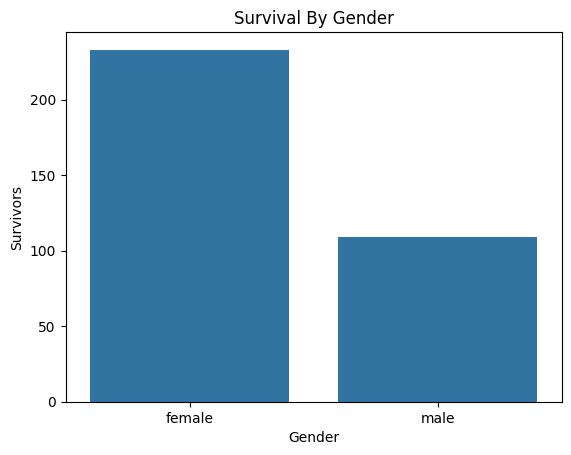

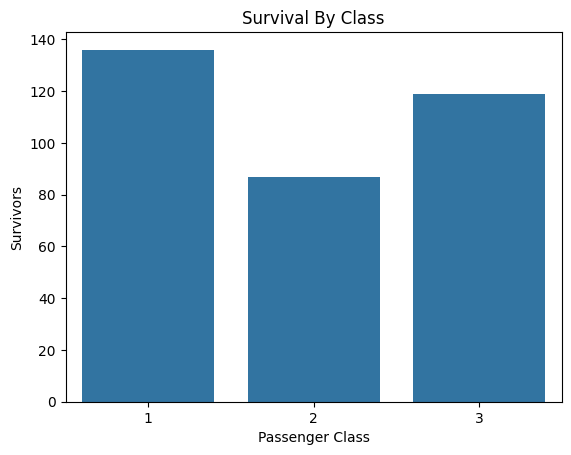

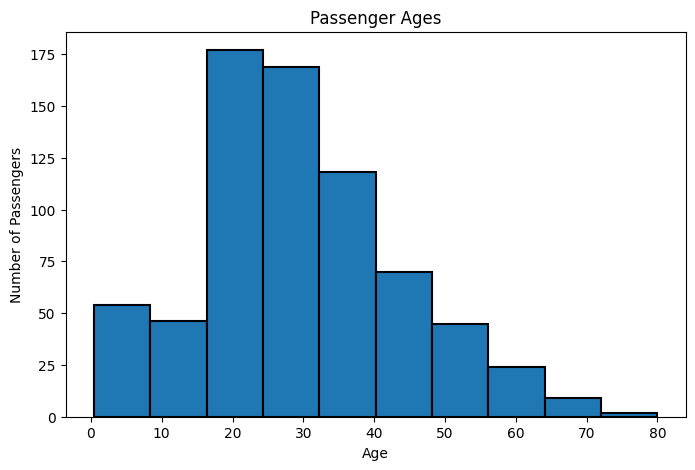

In [ ]:
sns.barplot(x="Sex",y="Count",data=survival_by_sex)
plt.title("Survival By Gender")
plt.xlabel("Gender")
plt.ylabel("Survivors")
plt.show()

sns.barplot(x="Pclass",y="Value",data=survival_by_class)
plt.title("Survival By Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survivors")
plt.show()

plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=10,edgecolor = "black",linewidth="1.5")
plt.title("Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

In [ ]:
# Conclusion

#The Titanic dataset was successfully cleaned and analyzed using Python, Pandas, Matplotlib, and Seaborn.

### Key Findings:
#- Missing values in the **Age** and **Embarked** columns were handled, and the **Cabin** column was removed due to a large number of missing values.
#- Female passengers had a significantly higher survival rate than male passengers.
#- Passenger class had a strong influence on survival, with first-class passengers having a better chance of survival than those in second and third class.
#- Most passengers were between **20 and 40 years** of age.
#- Children had a relatively higher survival rate compared to many adult passengers.

#Overall, gender, passenger class, and age were important factors influencing survival during the Titanic disaster. Exploratory Data Analysis helped identify these patterns through statistical summaries and visualizations.